In [1]:
import os

for root, dirs, files in os.walk('/kaggle/input/datasets/melekkchaou'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_val_waveforms.npy
/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_val_tabular_features.npy
/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_no_split_waveforms.npy
/kaggle/input/datasets/melekkchaou/echonext-waveforms/echonext_metadata_100k.csv
/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_no_split_tabular_features.npy
/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_train_waveforms.npy
/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_test_tabular_features.npy
/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_test_waveforms.npy
/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_train_tabular_features.npy


In [2]:
import numpy as np

X_train = np.load(
    "/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_train_waveforms.npy",
    mmap_mode="r"
)
X_val = np.load(
    "/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_val_waveforms.npy",
    mmap_mode="r"
)
X_test = np.load(
    "/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_test_waveforms.npy",
    mmap_mode="r"
)

In [3]:
import gc
import os                         
import numpy as np
from scipy.signal import butter, iirnotch, sosfiltfilt, tf2sos

OUTPUT_DIR = "/kaggle/working"     

#  Normalisation locale 
def local_zscore(X):
    """X : (N, 2500, 12) → normalisé par (ECG, dérivation)"""
    mu    = X.mean(axis=1, keepdims=True)
    sigma = X.std(axis=1,  keepdims=True)
    sigma = np.where(sigma == 0, 1.0, sigma)
    return (X - mu) / sigma

#  Filtres (conçus une seule fois) 
FS    = 250
FC_LP = 40
F0_NB = 50
Q_NB  = 30

sos_lp           = butter(N=4, Wn=FC_LP/(FS/2), btype='low', output='sos')
b_notch, a_notch = iirnotch(w0=F0_NB/(FS/2), Q=Q_NB)
sos_notch        = tf2sos(b_notch, a_notch)

#  Filtrage in-place par chunks 
CHUNK_SIZE = 500

def filter_inplace(X, name):
    N = len(X)
    for start in range(0, N, CHUNK_SIZE):
        end   = min(start + CHUNK_SIZE, N)
        chunk = X[start:end].copy()
        for lead in range(12):
            sig = chunk[:, :, lead]
            sig = sosfiltfilt(sos_lp,    sig, axis=1)
            sig = sosfiltfilt(sos_notch, sig, axis=1)
            chunk[:, :, lead] = sig
        X[start:end] = chunk
        del chunk
        if (start // CHUNK_SIZE) % 10 == 0:
            print(f"  {name} : {end}/{N} ECG filtrés...")
    print(f"✓ {name} terminé — shape : {X.shape}")

def save_split(X, name):
    path = f"{OUTPUT_DIR}/EchoNext_{name}_cleaned.npy"
    np.save(path, X)
    size_mb = os.path.getsize(path) / 1024**2
    print(f"✓ Sauvegardé → {path}  ({size_mb:.1f} MB)")
    return path

print("✓ Fonctions et filtres prêts.")

✓ Fonctions et filtres prêts.


# **TRAIN**

In [4]:
X_train_w1 = np.squeeze(X_train, axis=1)   # (72475, 2500, 12)
print("Shape après squeeze :", X_train_w1.shape)

Shape après squeeze : (72475, 2500, 12)


In [5]:
X_train_w1 = X_train_w1.astype(np.float32)
print("✓ Train converti en float32")

✓ Train converti en float32


In [6]:
X_train_w2 = local_zscore(X_train_w1)
del X_train_w1   #
gc.collect()
print("µ train (≈0) :", X_train_w2.mean())
print("σ train (≈1) :", X_train_w2.std())

µ train (≈0) : 4.583655e-06
σ train (≈1) : 1.0000001


In [7]:
filter_inplace(X_train_w2, "Train")
X_train_w3 = X_train_w2
del X_train_w2
gc.collect()

save_split(X_train_w3, "train")

del X_train_w3   # libère RAM, le fichier sera sur disque
gc.collect()
print("✓ Train terminé et déchargé de la RAM")

  Train : 500/72475 ECG filtrés...
  Train : 5500/72475 ECG filtrés...
  Train : 10500/72475 ECG filtrés...
  Train : 15500/72475 ECG filtrés...
  Train : 20500/72475 ECG filtrés...
  Train : 25500/72475 ECG filtrés...
  Train : 30500/72475 ECG filtrés...
  Train : 35500/72475 ECG filtrés...
  Train : 40500/72475 ECG filtrés...
  Train : 45500/72475 ECG filtrés...
  Train : 50500/72475 ECG filtrés...
  Train : 55500/72475 ECG filtrés...
  Train : 60500/72475 ECG filtrés...
  Train : 65500/72475 ECG filtrés...
  Train : 70500/72475 ECG filtrés...
✓ Train terminé — shape : (72475, 2500, 12)
✓ Sauvegardé → /kaggle/working/EchoNext_train_cleaned.npy  (8294.1 MB)
✓ Train terminé et déchargé de la RAM


# **TEST**

In [8]:
X_test_w1 = np.squeeze(X_test, axis=1)   # (5442, 2500, 12)
print("Shape après squeeze :", X_test_w1.shape)

Shape après squeeze : (5442, 2500, 12)


In [9]:
X_test_w1 = X_test_w1.astype(np.float32)
print("✓ Test converti en float32")

✓ Test converti en float32


In [10]:
X_test_w2 = local_zscore(X_test_w1)
del X_test_w1
gc.collect()
print("µ test (≈0) :", X_test_w2.mean())
print("σ test (≈1) :", X_test_w2.std())

µ test (≈0) : -1.4935875e-08
σ test (≈1) : 1.0000001


In [11]:
filter_inplace(X_test_w2, "Test")
X_test_w3 = X_test_w2
del X_test_w2
gc.collect()

save_split(X_test_w3, "test")

del X_test_w3
gc.collect()
print("✓ Test terminé et déchargé de la RAM")

  Test : 500/5442 ECG filtrés...
  Test : 5442/5442 ECG filtrés...
✓ Test terminé — shape : (5442, 2500, 12)
✓ Sauvegardé → /kaggle/working/EchoNext_test_cleaned.npy  (622.8 MB)
✓ Test terminé et déchargé de la RAM


# **VALIDATION**

In [12]:
X_val_w1 = np.squeeze(X_val, axis=1)   # (4626, 2500, 12)
print("Shape après squeeze :", X_val_w1.shape)

Shape après squeeze : (4626, 2500, 12)


In [13]:
X_val_w1 = X_val_w1.astype(np.float32)
print("✓ Val converti en float32")

✓ Val converti en float32


In [14]:
X_val_w2 = local_zscore(X_val_w1)
del X_val_w1
gc.collect()
print("µ val (≈0) :", X_val_w2.mean())
print("σ val (≈1) :", X_val_w2.std())

µ val (≈0) : -1.592871e-08
σ val (≈1) : 1.0000001


In [15]:
filter_inplace(X_val_w2, "Val")
X_val_w3 = X_val_w2
del X_val_w2
gc.collect()

save_split(X_val_w3, "val")

del X_val_w3
gc.collect()
print("✓ Val terminé et déchargé de la RAM")

  Val : 500/4626 ECG filtrés...
✓ Val terminé — shape : (4626, 2500, 12)
✓ Sauvegardé → /kaggle/working/EchoNext_val_cleaned.npy  (529.4 MB)
✓ Val terminé et déchargé de la RAM


# Vérification finale

In [16]:
import os

print("=== Fichiers dans /kaggle/working ===")
for f in sorted(os.listdir("/kaggle/working")):
    if f.endswith(".npy"):
        path = f"/kaggle/working/{f}"
        size_mb = os.path.getsize(path) / 1024**2
        print(f"  {f}  →  {size_mb:.1f} MB")

=== Fichiers dans /kaggle/working ===
  EchoNext_test_cleaned.npy  →  622.8 MB
  EchoNext_train_cleaned.npy  →  8294.1 MB
  EchoNext_val_cleaned.npy  →  529.4 MB


In [17]:
# Rechargement depuis /kaggle/working
X_train_w3 = np.load("/kaggle/working/EchoNext_train_cleaned.npy", mmap_mode="r")
X_test_w3  = np.load("/kaggle/working/EchoNext_test_cleaned.npy",  mmap_mode="r")
X_val_w3   = np.load("/kaggle/working/EchoNext_val_cleaned.npy",   mmap_mode="r")

print("=== Shapes finales ===")
print("Train :", X_train_w3.shape)
print("Test  :", X_test_w3.shape)
print("Val   :", X_val_w3.shape)

# Vérification sanité rapide
print("\n=== Sanité ===")
print(f"Train dtype : {X_train_w3.dtype}")
print(f"Train µ (≈0) : {X_train_w3.mean():.6f}")
print(f"Train σ (≈1) : {X_train_w3.std():.6f}")

=== Shapes finales ===
Train : (72475, 2500, 12)
Test  : (5442, 2500, 12)
Val   : (4626, 2500, 12)

=== Sanité ===
Train dtype : float32
Train µ (≈0) : 0.000005
Train σ (≈1) : 0.984339


         EchoNext — EDA signaux nettoyés (w3)

Train   shape=(72475, 2500, 12)  dtype=float32  8.10 GB
         µ=0.0000  σ=0.9843  min=-18.031  max=19.086

Test    shape=(5442, 2500, 12)  dtype=float32  0.61 GB
         µ=0.0000  σ=0.9846  min=-16.068  max=16.531

Val     shape=(4626, 2500, 12)  dtype=float32  0.52 GB
         µ=0.0000  σ=0.9847  min=-17.136  max=16.948


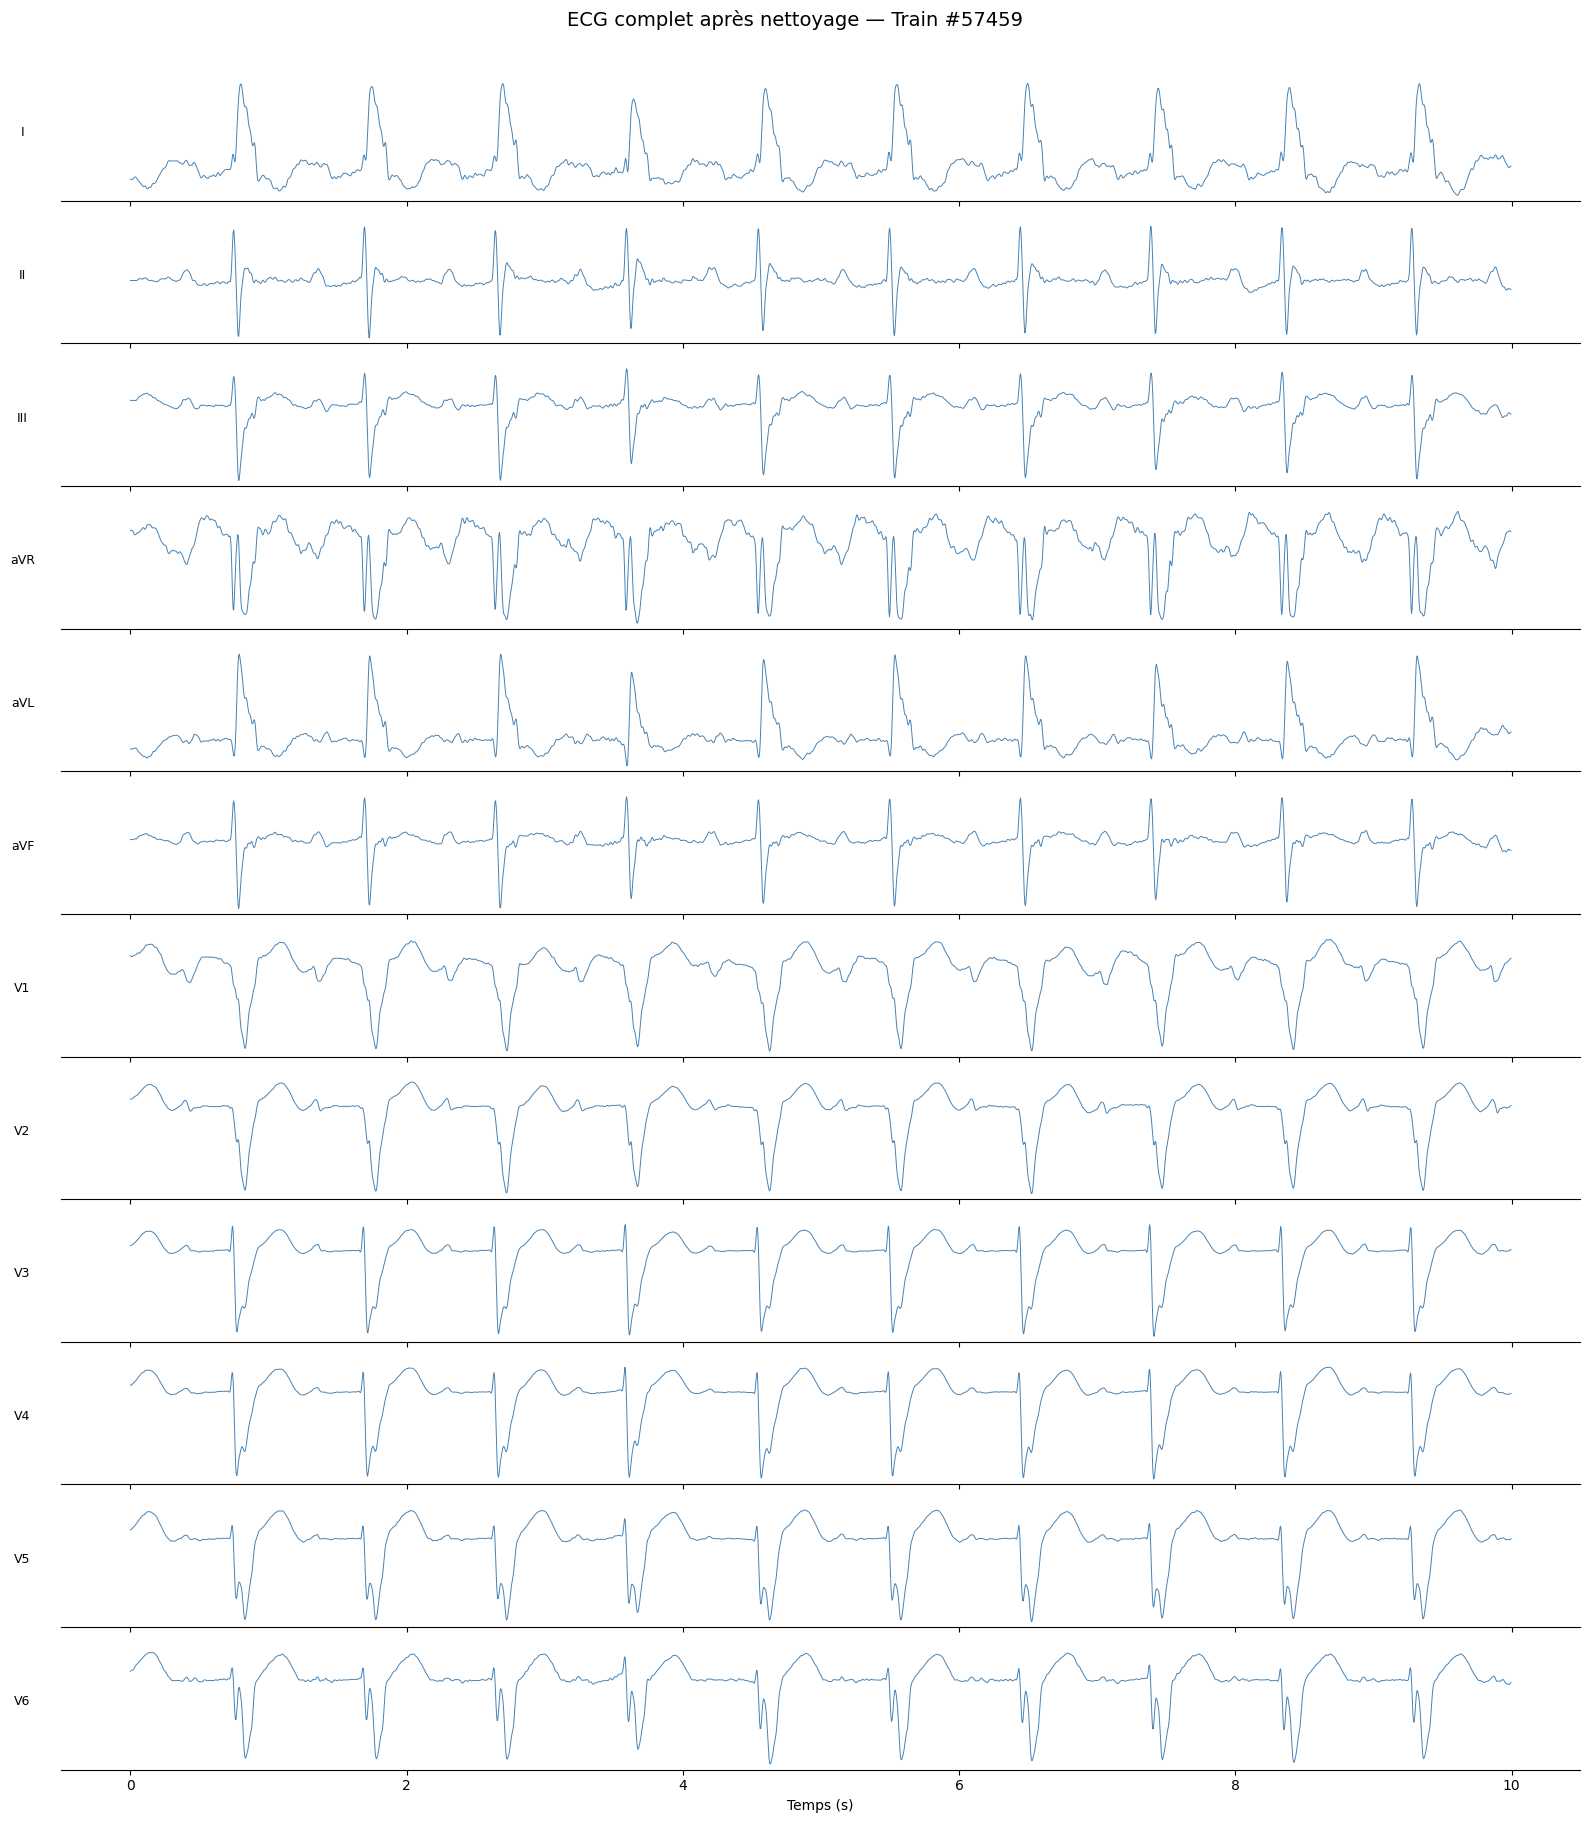

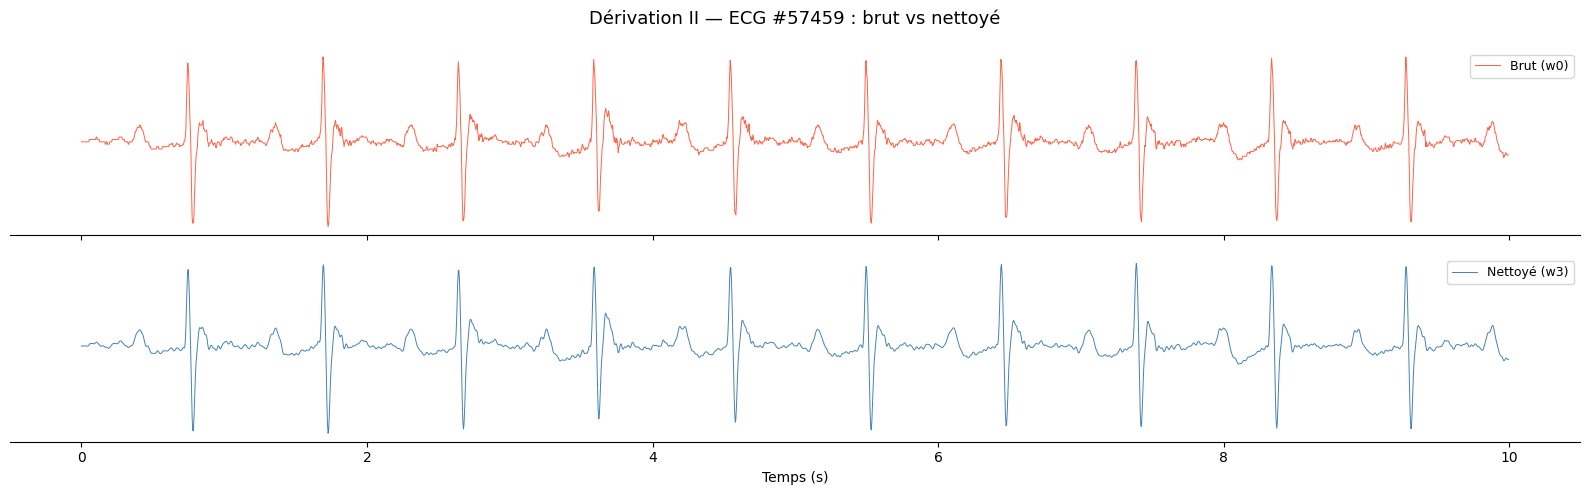

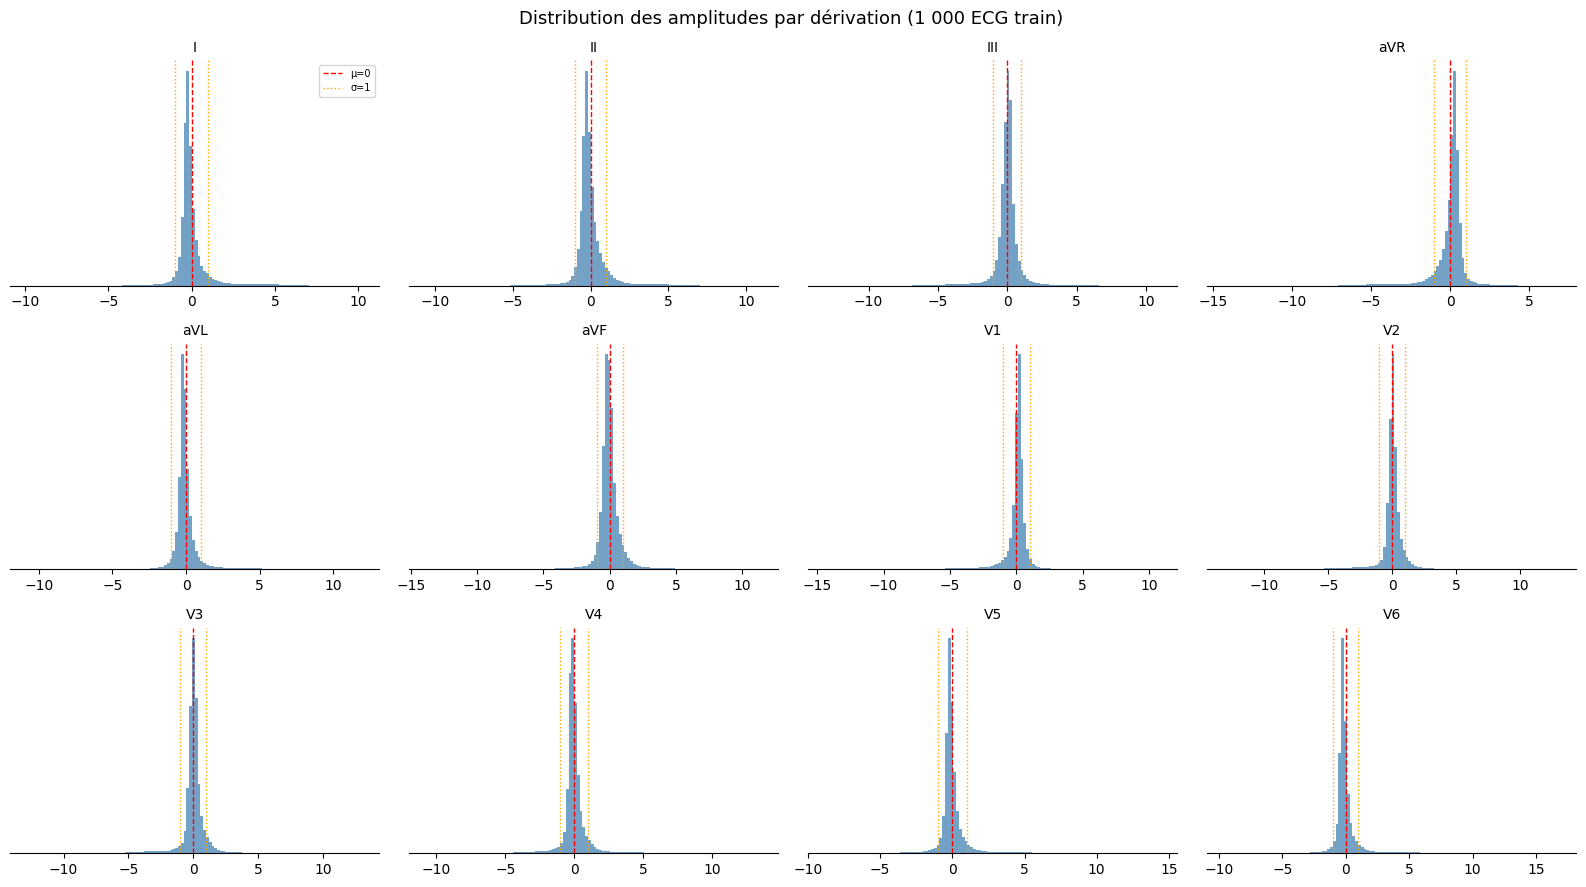

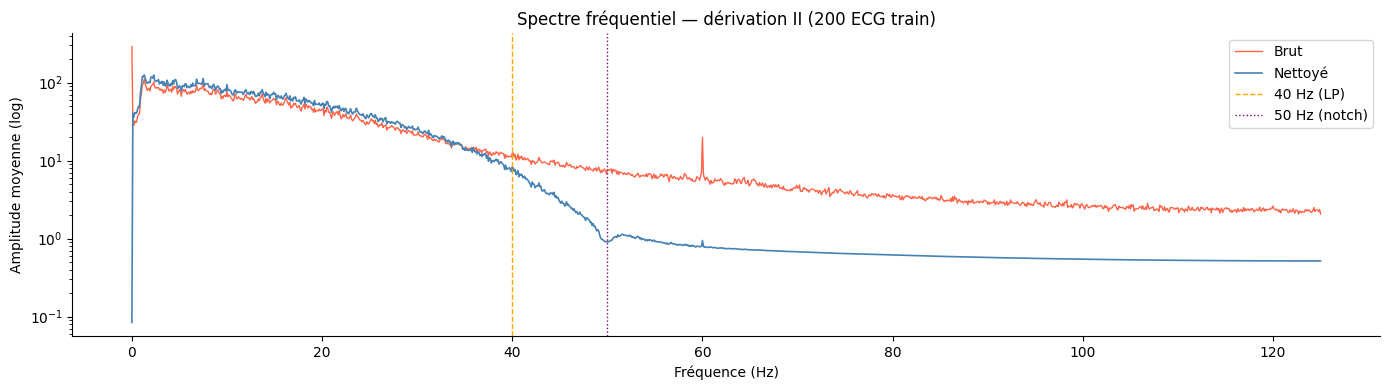


Lead          µ        σ      min      max   % flat
I        0.0005   0.9851   -9.896   11.393    0.05%
II       0.0000   0.9840  -10.722   11.446    0.00%
III      0.0000   0.9707  -13.163   15.835    0.00%
aVR     -0.0000   0.9869  -14.333    7.566    0.00%
aVL     -0.0000   0.9768  -12.589   13.231    0.00%
aVF      0.0000   0.9750  -14.466   13.510    0.00%
V1       0.0000   0.9901  -15.327   10.869    0.00%
V2      -0.0000   0.9892  -14.388   13.106    0.00%
V3       0.0000   0.9908  -14.888   13.043    0.00%
V4       0.0000   0.9881  -11.264   13.939    0.00%
V5       0.0000   0.9880  -10.227   14.569    0.00%
V6       0.0000   0.9882  -10.293   16.850    0.00%


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

#  Rechargement léger 
X_train_w3 = np.load("/kaggle/working/EchoNext_train_cleaned.npy", mmap_mode="r")
X_test_w3  = np.load("/kaggle/working/EchoNext_test_cleaned.npy",  mmap_mode="r")
X_val_w3   = np.load("/kaggle/working/EchoNext_val_cleaned.npy",   mmap_mode="r")

LEADS = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
FS    = 250
T     = np.arange(2500) / FS   

# 1. RÉSUMÉ GLOBAL
print("=" * 55)
print("         EchoNext — EDA signaux nettoyés (w3)")
print("=" * 55)
for name, X in [("Train", X_train_w3), ("Test", X_test_w3), ("Val", X_val_w3)]:
    print(f"\n{name:6s}  shape={X.shape}  dtype={X.dtype}  "
          f"{X.nbytes/1024**3:.2f} GB")
    print(f"         µ={X.mean():.4f}  σ={X.std():.4f}  "
          f"min={X.min():.3f}  max={X.max():.3f}")

# 2. UN ECG COMPLET — 12 DÉRIVATIONS (échantillon aléatoire)
idx = np.random.randint(len(X_train_w3))
ecg = np.array(X_train_w3[idx])          # (2500, 12) — copie en RAM

fig, axes = plt.subplots(12, 1, figsize=(16, 18), sharex=True)
fig.suptitle(f"ECG complet après nettoyage — Train #{idx}", fontsize=14, y=1.01)
for i, ax in enumerate(axes):
    ax.plot(T, ecg[:, i], lw=0.7, color="steelblue")
    ax.set_ylabel(LEADS[i], rotation=0, labelpad=28, fontsize=9)
    ax.set_yticks([])
    ax.spines[["top","right","left"]].set_visible(False)
axes[-1].set_xlabel("Temps (s)")
plt.tight_layout()
plt.show()

# 3. COMPARAISON AVANT / APRÈS NETTOYAGE — dérivation II
#    (recharge w2 depuis le mmap original pour comparer)
try:
    X_raw = np.load(
        "/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_train_waveforms.npy",
        mmap_mode="r"
    )
    raw_sig     = np.squeeze(X_raw[idx], axis=0)[:, 1].astype(np.float32)
    cleaned_sig = ecg[:, 1]

    fig, axes = plt.subplots(2, 1, figsize=(16, 5), sharex=True)
    fig.suptitle(f"Dérivation II — ECG #{idx} : brut vs nettoyé", fontsize=13)
    axes[0].plot(T, raw_sig,     lw=0.7, color="tomato",    label="Brut (w0)")
    axes[1].plot(T, cleaned_sig, lw=0.7, color="steelblue", label="Nettoyé (w3)")
    for ax in axes:
        ax.legend(loc="upper right", fontsize=9)
        ax.set_yticks([])
        ax.spines[["top","right","left"]].set_visible(False)
    axes[1].set_xlabel("Temps (s)")
    plt.tight_layout()
    plt.show()
except Exception:
    print("(comparaison brut/nettoyé ignorée — fichier source non accessible)")


# 4. DISTRIBUTION DES AMPLITUDES PAR DÉRIVATION (Train, 1000 ECG)
sample = np.array(X_train_w3[:1000])   # (1000, 2500, 12)

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
fig.suptitle("Distribution des amplitudes par dérivation (1 000 ECG train)", fontsize=13)
for i, ax in enumerate(axes.flat):
    vals = sample[:, :, i].ravel()
    ax.hist(vals, bins=120, color="steelblue", alpha=0.75, density=True)
    ax.axvline(0, color="red",    lw=1, linestyle="--", label="µ=0")
    ax.axvline(1, color="orange", lw=1, linestyle=":",  label="σ=1")
    ax.axvline(-1,color="orange", lw=1, linestyle=":")
    ax.set_title(LEADS[i], fontsize=10)
    ax.set_yticks([])
    ax.spines[["top","right","left"]].set_visible(False)
    if i == 0:
        ax.legend(fontsize=7)
plt.tight_layout()
plt.show()
del sample

# 5. SPECTRE DE FRÉQUENCE — avant/après filtre (dérivation II, 200 ECG)
try:
    from numpy.fft import rfft, rfftfreq

    freqs    = rfftfreq(2500, d=1/FS)
    raw_200  = np.squeeze(X_raw[:200], axis=1)[:, :, 1].astype(np.float32)
    cln_200  = np.array(X_train_w3[:200, :, 1])

    psd_raw = np.abs(rfft(raw_200, axis=1)).mean(axis=0)
    psd_cln = np.abs(rfft(cln_200, axis=1)).mean(axis=0)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.semilogy(freqs, psd_raw, color="tomato",    lw=1,   label="Brut")
    ax.semilogy(freqs, psd_cln, color="steelblue", lw=1.2, label="Nettoyé")
    ax.axvline(40, color="orange", lw=1, linestyle="--", label="40 Hz (LP)")
    ax.axvline(50, color="purple", lw=1, linestyle=":",  label="50 Hz (notch)")
    ax.set_xlabel("Fréquence (Hz)")
    ax.set_ylabel("Amplitude moyenne (log)")
    ax.set_title("Spectre fréquentiel — dérivation II (200 ECG train)")
    ax.legend()
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
    del raw_200, cln_200
except Exception:
    print("(spectre ignoré — fichier source non accessible)")

# 6. STATS GLOBALES PAR DÉRIVATION
sample2 = np.array(X_train_w3[:2000])
print("\n{:<6} {:>8} {:>8} {:>8} {:>8} {:>8}".format(
      "Lead","µ","σ","min","max","% flat"))
for i in range(12):
    v       = sample2[:, :, i]
    flat_pct = (v.std(axis=1) < 1e-4).mean() * 100
    print("{:<6} {:>8.4f} {:>8.4f} {:>8.3f} {:>8.3f} {:>7.2f}%".format(
          LEADS[i], v.mean(), v.std(), v.min(), v.max(), flat_pct))
del sample2